# **DCA analysis using adabmDCA**

---


In [5]:
# # @title Setup adabmDCA

import os
import sys
import subprocess
import io
from contextlib import redirect_stdout, redirect_stderr
import importlib
#from google.colab import files
import torch
import numpy as np
import matplotlib.pyplot as plt

# print("Installing dependences...")
# !python -m pip install biopython

# # Install adabmDCA (only if not already installed)
# if not os.path.isdir("adabmDCApy"):
#     print("Setting up adabmDCA...")

#     # Capture output for git clone
#     GIT_REPO = 'https://github.com/spqb/adabmDCApy'
#     TMP_DIR = "tmp"
#     os.makedirs(TMP_DIR, exist_ok=True)

#     result = subprocess.run(
#         f"git clone {GIT_REPO}.git",
#         shell=True,
#         capture_output=True,
#         text=True
#     )

#     # Capture pip install output
#     with io.StringIO() as buf, redirect_stdout(buf), redirect_stderr(buf):
#         subprocess.run(
#             ["pip", "install", "-e", "adabmDCApy/", "--no-deps"],
#             capture_output=True,
#             text=True
#         )
#         # Only if additional dependences are needed
#         #subprocess.run(
#         #    ["pip", "install", "biopython"],
#         #    capture_output=True,
#         #    text=True
#         #)

#     # enter the develop branch
#     result = subprocess.run(
#         "cd adabmDCApy && git checkout develop && cd ..",
#         shell=True,
#         capture_output=True,
#         text=True
#     )

#     importlib.invalidate_caches()
#     # Add the package to Python path
#     package_path = os.path.abspath("adabmDCApy")
#     if package_path not in sys.path:
#         sys.path.insert(0, package_path)

#     print("✓ adabmDCA installed successfully")

# Import adabmDCA modules
from adabmDCA.fasta import get_tokens, import_from_fasta, compute_weights
from adabmDCA.stats import get_freq_single_point, get_freq_two_points
from adabmDCA.functional import one_hot
from adabmDCA.utils import init_parameters, init_chains, get_device, get_dtype, get_mask_save
from adabmDCA.sampling import get_sampler
from adabmDCA.training import train_graph, train_edDCA, train_eaDCA
from adabmDCA.io import save_params, save_chains, load_params
from adabmDCA.graph import compute_density

# # Initialize device
# # Set the device
device = get_device("cpu")
dtype = get_dtype("float32")

Running on CPU


## Train and sample from a DCA model

In [ ]:
# @title Settings

jobname = "DCA_model_PF0014" # @param {"type":"string"}
path_data= "PF00014_noinsert_max02gap.faa"

os.makedirs(jobname, exist_ok=True)
path_params = os.path.join(jobname, f"{jobname}_params.dat")
path_chains = os.path.join(jobname, f"{jobname}_chains.fasta")

tokens = get_tokens("protein")


# Import sequences
headers, sequences = import_from_fasta(path_data, tokens=tokens, filter_sequences=True, remove_duplicates=True)
M, L, q = len(sequences), len(sequences[0]), len(tokens)
print(f"Number of sequences in the MSA: M={M}")
print(f"Length of the MSA: L={L}")
print(f"Number of Potts states: q={q}")

msa_enc = torch.tensor(sequences, device=device, dtype=torch.int32)

weights = compute_weights(msa_enc, device=device, dtype=dtype)
M_eff = int(weights.sum())
msa_oh = one_hot(msa_enc, num_classes=q).to(dtype)

# Save weights in the output folder
path_weights = os.path.join(jobname, f"{jobname}_weights.dat")
np.savetxt(path_weights, weights.cpu().numpy())

print(f"Effective number of chains: M_eff={M_eff}")
print(f"Sequence weights saved in {path_weights}")

Unknown token found: removing sequence A0A6J2RG50_COTGO/2637-2690
Unknown token found: removing sequence A0A3P6SK92_ANISI/95-141
Unknown token found: removing sequence A0A6A1QI53_BALPH/123-176
Unknown token found: removing sequence ATPI1_ACTTE/160-212
Unknown token found: removing sequence R0LE02_ANAPL/727-780
Unknown token found: removing sequence A0A6P5BPR2_BOSIN/3164-3216
Unknown token found: removing sequence A0A914TYU6_9BILA/188-239
Unknown token found: removing sequence A0AAJ7DU47_9HYME/1977-2029
Unknown token found: removing sequence A0A913XHX0_EXADI/257-310
Unknown token found: removing sequence A0A6P5CPN0_BOSIN/39-91
Unknown token found: removing sequence IBPC_BOVIN/7-59
Unknown token found: removing sequence A0A913YRK7_EXADI/2105-2159
Unknown token found: removing sequence A0A914TXI8_9BILA/188-239
Unknown token found: removing sequence A0A8D0E446_SALMN/78-130
Unknown token found: removing sequence A0A6P5CRJ4_BOSIN/123-175
Unknown token found: removing sequence R0JWU6_ANAPL/52

In [11]:
#@markdown **Train the model / load parameters**

#@markdown Run this cell to load the parameters from the uploaded file or train a bmDCA model

#@markdown ---

#@markdown **Training routine**

#@markdown Choose the learning strategy. The possibilities are:

#@markdown - `None` - Only uploads the model parameters;
#@markdown - `bmDCA` - Fully connected Potts model;
#@markdown - `eaDCA` - Element activation (sparse, bottom-up) Potts model. The training routine starts from an empty graph and gradually adds couplings until the target Pearson score is reached.
#@markdown - `edDCA` - Element decimation (sparse, top-down) Potts model. Starts from a fully connected graph and prunes couplings until a target sparsity is reached, always mantaining the Pearson score above a target value.

routine = "bmDCA" # @param ["None", "bmDCA", "eaDCA", "edDCA"]

#@markdown ---

#@markdown **General hyperparameters**

pseudo_count = 0.001 # @param ["1/M_eff", "0.01", "0.001", "0.0001"]{"type":"raw"}
nchains = 10000 # @param {"type":"integer"}
nsweeps = 10 # @param {"type":"integer"}
target = 0.80 # @param {"type":"number"}
lr = 0.01 # @param {"type":"number"}
sampler_alg = "gibbs" # @param ["gibbs", "metropolis"]

#@markdown ---
#@markdown **`eaDCA` - specific arguments**

#@markdown Number of gradient updates to be performed on a given graph
gsteps = 10 # @param {"type":"integer"}
#@markdown Fraction of inactive couplings to be proposed for activation at each graph update
factivate = 0.001 # @param {"type":"number"}

#@markdown ---

#@markdown **`edDCA` - specific arguments**

#@markdown Target density to be reached
target_density = 0.5 # @param {"type":"number"}
#@markdown Fraction of remaining couplings to be pruned at each decimation step.
drate = 0.01 # @param {"type":"number"}


training_routines = {
    "bmDCA": train_graph,
    "eaDCA": train_eaDCA,
    "edDCA": train_edDCA
}
train_routine = training_routines[routine]

if pseudo_count == "1/M_eff":
    pseudocount = 1 / M_eff
else:
    pseudocount = float(pseudo_count)
fi_target = get_freq_single_point(data=msa_oh, weights=weights, pseudo_count=pseudocount)
fij_target = get_freq_two_points(data=msa_oh, weights=weights, pseudo_count=pseudocount)

sampler = torch.jit.script(get_sampler(sampler_alg))
print("Using sampler:", sampler_alg)
print(f"Using pseudo count: {pseudocount:.4f}")


if routine != "None":

    print("Initializing training parameters...")
    params = init_parameters(fi=fi_target)
    if routine in ["bmDCA", "edDCA"]:
        mask = torch.ones(size=(L, q, L, q), dtype=torch.bool, device=device)
        mask[torch.arange(L), :, torch.arange(L), :] = 0
        density = compute_density(mask) * 100
        print(f"Model density: {density:.3f}%")
    else:
        mask = torch.zeros(size=(L, q, L, q), device=device, dtype=torch.bool)
        density = compute_density(mask) * 100
        print(f"Model density: {density:.3f}%")
    chains = init_chains(num_chains=nchains, L=L, q=q, device=device, fi=fi_target)

    log_weights = torch.zeros(len(chains), device=device)
    # Mask for saving only the upper diagnal part of the weight_matrix
    mask_save = get_mask_save(L=L, q=q, device=device)

    print(f"Training {routine} model...")
    chains, params, log_weights, history = train_routine(
    sampler=sampler,
    chains=chains,
    fi_target=fi_target,
    fij_target=fij_target,
    params=params,
    mask=mask,
    nsweeps=nsweeps,
    lr=lr,
    max_epochs=10000,
    target_pearson=target,
    gsteps=gsteps,
    factivate=factivate,
    target_density=target_density,
    drate=drate,
    log_weights=log_weights,
    pseudo_count=pseudocount,
    checkpoint=None,
    )

    fig, ax = plt.subplots(1, 1, figsize=(8, 4), dpi=100)
    ax.plot(history["Epochs"], history["Pearson"], label="Pearson training")
    ax.axhline(target, ls="--", color="red", label="Training target")
    ax.set_xlabel("Epochs", fontsize=15)
    ax.set_ylabel(r"Pearson $C_{ij}$ correlation", fontsize=15)
    ax.legend(fontsize=15)
    fig.tight_layout()




Using sampler: gibbs
Using pseudo count: 0.0010
Initializing training parameters...
Model density: 100.000%
Training bmDCA model...


Epochs: 117 - LL: -90.81:  20.05%[##--------] Pearson: 0.160/0.8 [21:02]

KeyboardInterrupt: 

In [1]:
from adabmDCA import load_params, get_tokens
path_params="DCA_model/DCA_model_params.dat"
device = "cpu"
tokens = get_tokens("protein")
params = load_params(path_params, tokens=tokens, device=device)

In [ ]:
Jij = params["coupling_matrix"]
print(Jij.shape)

torch.Size([53, 21])


In [72]:
def set_zerosum_gauge(params: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    """Sets the zero-sum gauge on the coupling matrix.
    
    Args:
        params (Dict[str, torch.Tensor]): Parameters of the model.
        
    Returns:
        Dict[str, torch.Tensor]: New dictionary with modified coupling matrix.
            "bias": torch.Tensor of shape (L, q)
            "coupling_matrix": torch.Tensor of shape (L, q, L, q)
    """
    params = {key: value.clone() for key, value in params.items()}
    coupling_matrix = params["coupling_matrix"]
    coupling_matrix -= coupling_matrix.mean(dim=1, keepdim=True) + \
                       coupling_matrix.mean(dim=3, keepdim=True) - \
                       coupling_matrix.mean(dim=(1, 3), keepdim=True)
    
    params["coupling_matrix"] = coupling_matrix
    
    return params



def get_contact_map_new(
    params: Dict[str, torch.Tensor],
    tokens: str,
) -> np.ndarray:
    """
    Computes the contact map from the model coupling matrix.

    Args:
        params (Dict[str, torch.Tensor]): Model parameters. Should contain:
            - "coupling_matrix": torch.Tensor of shape (L, q, L, q)
            - "bias": torch.Tensor of shape (L, q)
        tokens (str): Alphabet to be used.

    Returns:
        np.ndarray: Contact map.
    """
    q = params["coupling_matrix"].shape[1]
    device = params["coupling_matrix"].device

    # Zero-sum gauge  
    params = set_zerosum_gauge(params)
    
    # Get index of the gap symbol
    if "-" not in tokens:
        raise ValueError(f"Gap symbol '-' not found in alphabet: {tokens}")
    gap_idx = tokens.index("-")
    
    Jij = params["coupling_matrix"]
    # Take all the entries of the coupling matrix except where the gap is involved
    mask = torch.arange(q, device=device) != gap_idx
    Jij_reduced = Jij[:, mask, :, :][:, :, :, mask]

    # Compute the Frobenius norm
    cm = torch.sqrt(torch.square(Jij).sum([1, 3]))
    # Set to zero the diagonal
    cm = cm - torch.diag(cm.diag())
    # Compute the average-product corrected Frobenius norm
    Fapc = cm - torch.outer(cm.sum(1), cm.sum(0)) / cm.sum()
    # set to zero the diagonal
    Fapc = Fapc - torch.diag(Fapc.diag())

    return Fapc.cpu().numpy()


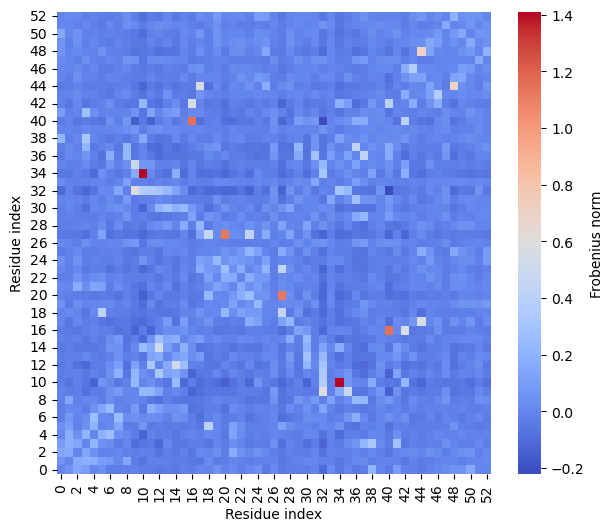

In [83]:
from adabmDCA.dca import get_contact_map
from adabmDCA.plot import plot_contact_map
import matplotlib.pyplot as plt
dpi = 100 #@param {"type": "integer"}


cm = get_contact_map(params=params, tokens=tokens)
#cm = get_contact_map_true(params=params, tokens=tokens)

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=dpi)
ax = plot_contact_map(ax=ax, cm=cm)

In [74]:
from sequenceHandler import mapPDBToHMM
pdb_file = "5PTI.pdb"
chain_id = "A"
hmm_file = "PF00014.hmm"
hmm_file_2 = "None"        
output_map_file = "distance_map.txt"  

dm,mi = mapPDBToHMM(pdb_file, chain_id, hmm_file, hmm_file_2, output_map_file, distType='all')
print(dm)
print(mi)

c:\Users\gfabi\miniconda3\envs\Internship\Lib\site-packages\Bio\PDB\Atom.py:237: PDBConstructionWarning: Used element 'U' for Atom (name=UNK) with given element 'X'
  warnings.warn(msg, PDBConstructionWarning)


[<Residue ARG het=  resseq=1 icode= >, <Residue PRO het=  resseq=2 icode= >, <Residue ASP het=  resseq=3 icode= >, <Residue PHE het=  resseq=4 icode= >, <Residue CYS het=  resseq=5 icode= >, <Residue LEU het=  resseq=6 icode= >, <Residue GLU het=  resseq=7 icode= >, <Residue PRO het=  resseq=8 icode= >, <Residue PRO het=  resseq=9 icode= >, <Residue TYR het=  resseq=10 icode= >, <Residue THR het=  resseq=11 icode= >, <Residue GLY het=  resseq=12 icode= >, <Residue PRO het=  resseq=13 icode= >, <Residue CYS het=  resseq=14 icode= >, <Residue LYS het=  resseq=15 icode= >, <Residue ALA het=  resseq=16 icode= >, <Residue ARG het=  resseq=17 icode= >, <Residue ILE het=  resseq=18 icode= >, <Residue ILE het=  resseq=19 icode= >, <Residue ARG het=  resseq=20 icode= >, <Residue TYR het=  resseq=21 icode= >, <Residue PHE het=  resseq=22 icode= >, <Residue TYR het=  resseq=23 icode= >, <Residue ASN het=  resseq=24 icode= >, <Residue ALA het=  resseq=25 icode= >, <Residue LYS het=  resseq=26 icod

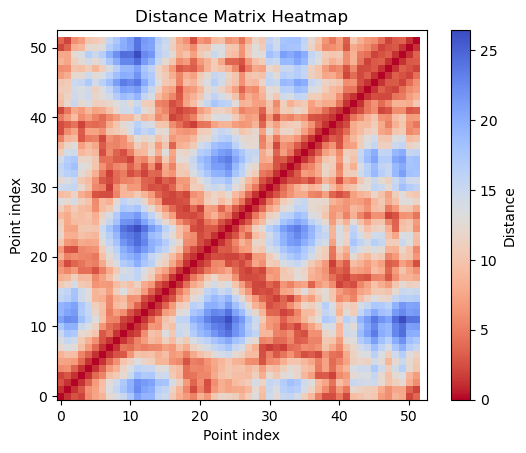

In [68]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(dm,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="Distance")
plt.title("Distance Matrix Heatmap")
plt.xlabel("Point index")
plt.ylabel("Point index")

plt.show()

In [48]:
def top_k(matrix, k, min_sep=5):
    L = matrix.shape[0]
    
    i, j = np.triu_indices(L, k=1)

    mask = (j - i) >= min_sep
    i, j = i[mask], j[mask]
    
    values = matrix[i, j]
    
    topk_idx = np.argpartition(values, -k)[-k:]
    topk_idx = topk_idx[np.argsort(values[topk_idx])[::-1]]
    
    return values[topk_idx], i[topk_idx], j[topk_idx]

Rank 1: Residue pair (10, 34) with score 1.4287089109420776 and distance 2.030236507854587
Rank 2: Residue pair (16, 40) with score 1.1669143438339233 and distance 1.945920458537459
Rank 3: Residue pair (20, 27) with score 1.145789623260498 and distance 1.8150817744967482
Rank 4: Residue pair (1, 2) with score 1.014453411102295 and distance 1.2908700534687192
Rank 5: Residue pair (1, 3) with score 0.8760655522346497 and distance 2.838320691791071
Rank 6: Residue pair (1, 4) with score 0.7248657941818237 and distance 6.1232233380009635
Rank 7: Residue pair (44, 48) with score 0.7061940431594849 and distance 1.8580143987049966
Rank 8: Residue pair (2, 3) with score 0.6312953233718872 and distance 1.3241795701247363
Rank 9: Residue pair (50, 51) with score 0.5993906855583191 and distance 1.3376111675037685
Rank 10: Residue pair (9, 32) with score 0.598869800567627 and distance 4.930810426806165
Rank 11: Residue pair (17, 44) with score 0.582815408706665 and distance 2.6239891941334093
Ran

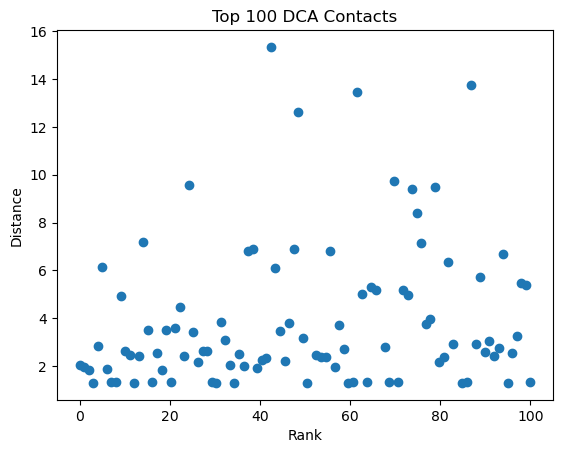

In [75]:
k=100
values, i, j = top_k(cm, k=k, min_sep=0)
d=[]
for n in range(k):
    distance = dm[i[n], j[n]]
    d.append(distance)
    print(f"Rank {n+1}: Residue pair ({i[n]}, {j[n]}) with score {values[n]} and distance {distance}")
plt.plot(np.linspace(0, k, k),d, 'o')
plt.xlabel('Rank')
plt.ylabel('Distance')
plt.title(f'Top {k} DCA Contacts')
plt.show()


(1378, 3)


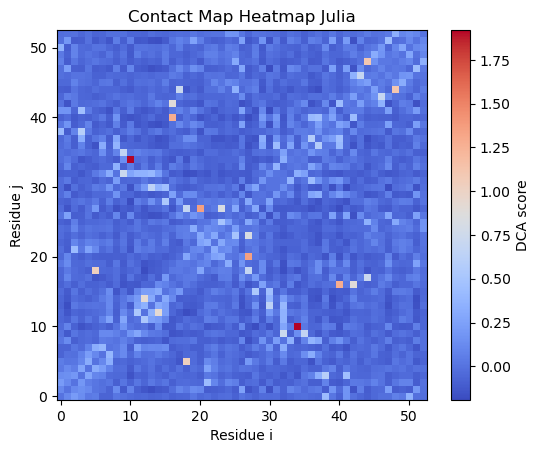

In [103]:
#Julia code to plot the contact map from the scores.csv file
import subprocess

julia_code = """
using PlmDCA, DelimitedFiles
X = plmdca("C:/Users/gfabi/Desktop/Internship/DCA_model/PF00014_noinsert_max02gap.faa")
writedlm("scores.csv", X.score, ',')
"""

subprocess.run(["julia", "-e", julia_code])

data = np.loadtxt("scores.csv", delimiter=",")
print(data.shape)
# data columns: i, j, score
i = data[:, 0].astype(int)
j = data[:, 1].astype(int)
s = data[:, 2]

# Build matrix
N = int(max(i.max(), j.max()))
score_map = np.zeros((N, N))

for ii, jj, val in zip(i, j, s):
    score_map[ii-1, jj-1] = val
    score_map[jj-1, ii-1] = val

# Plot
plt.figure()
plt.imshow(score_map,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA score")
plt.title("Contact Map Heatmap Julia")
plt.xlabel("Residue i")
plt.ylabel("Residue j")

plt.show()

In [93]:
N = int(max(i.max(), j.max())) + 1
print(i)

[11 21 17 ... 28 13 31]


(53, 53)
(53, 53)


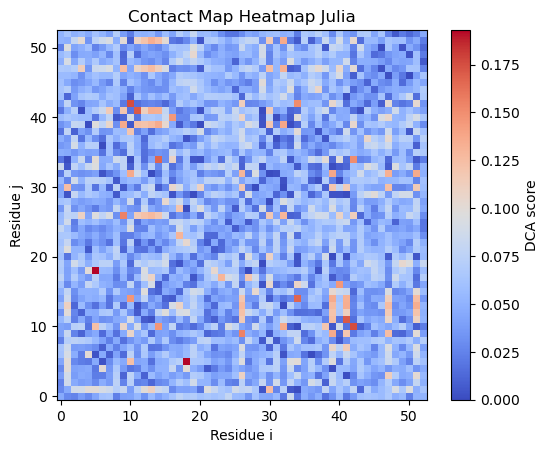

In [97]:
#Comparison between Julia and Python contact maps   
print(cm.shape)
print(score_map.shape)

cm_normalized= (cm - np.min(cm)) / (np.max(cm) - np.min(cm))
score_map_normalized = (score_map - np.min(score_map)) / (np.max(score_map) - np.min(score_map))    
a=abs(cm_normalized-score_map_normalized)

# Plot
plt.figure()
plt.imshow(a,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA score")
plt.title("Contact Map Heatmap Julia")
plt.xlabel("Residue i")
plt.ylabel("Residue j")

plt.show()

In [ ]:
#@title Download model parameters

#@markdown Once this cell has been executed, a zip-archive with
#@markdown the obtained model parameters will be automatically downloaded
#@markdown to your computer.

if params_method == "Train model":
    # Save parameters and chains
    save_params(fname=path_params, params=params, mask=mask_save, tokens=tokens)
    save_chains(fname=path_chains, chains=chains.argmax(-1), tokens=tokens, log_weights=log_weights)

    os.system(f"zip -r {jobname}.zip {jobname}")
    files.download(f'{jobname}.zip')

else:
    print("Nothing to save.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  0%|          | 0/5000 [00:00<?, ?it/s]

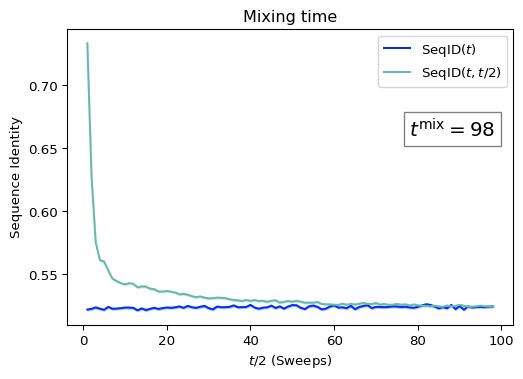

Sampling for 196 sweeps starting from random initialization


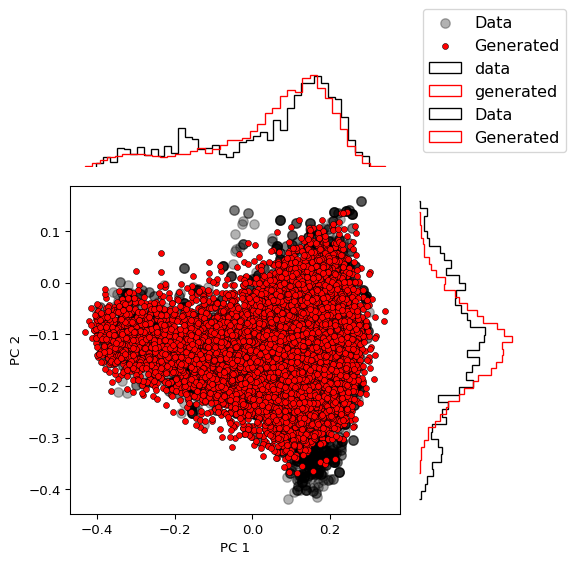

In [ ]:
# @title Sample from the DCA model

from adabmDCA.io import load_params, load_chains
from adabmDCA.resampling import compute_mixing_time
from adabmDCA.utils import resample_sequences

get_mixing_time = True #@param {type:"boolean"}
max_sweeps = 5000 # @param {"type": "integer"}
num_gen = 10000 # @param {"type": "integer"}
sampler_alg = "gibbs" # @param ["gibbs", "metropolis"]
sampler = get_sampler(sampler_alg)
#@markdown Choose one of the following options for the number of sweeps to use in the simulation:
num_mixing_times = 2 # @param {"type": "integer"}
num_sweeps = None # @param {"type": "raw"}
#@markdown If `num_sweeps` is **None**, the routine will sample sequences for `num_mixing_time` times the estimated mixing time.
beta = 1.0 # @param {"type": "number"}

# Take a subsample of the data that will be used for computing the mixing time. Data are picked with probability proportional to their statistical weight
msa_mix = resample_sequences(msa_oh, weights=weights, nextract=M)
if get_mixing_time:
    results = compute_mixing_time(
        sampler=sampler,
        params=params,
        data=msa_mix,
        n_max_sweeps=max_sweeps,
        beta=1.0,
    )

    fig = plt.figure(figsize=(6, 4), dpi=96)
    plt.plot(results["t_half"], results["seqid_t"], label=r"SeqID$(t)$", color="#002CFF")  # Blue
    plt.fill_between(results["t_half"],
                     np.array(results["seqid_t"]) - np.array(results["std_seqid_t"]),
                     np.array(results["seqid_t"]) + np.array(results["std_seqid_t"]),
                     color="#002CFF", alpha=0.2)
    plt.plot(results["t_half"], results["seqid_t_t_half"], label=r"SeqID$(t, t/2)$", color="#67BAA6")  # Orange
    plt.fill_between(results["t_half"],
                     np.array(results["seqid_t_t_half"]) - np.array(results["std_seqid_t_t_half"]),
                     np.array(results["seqid_t_t_half"]) + np.array(results["std_seqid_t_t_half"]),
                     color="#67BAA6", alpha=0.2)
    plt.xlabel(r"$t/2$ (Sweeps)")
    plt.ylabel("Sequence Identity")
    plt.legend(loc='upper right')
    plt.title("Mixing time")


    # Add annotation for mixing time
    plt.annotate(r"$t^{\mathrm{mix}}=$" + f"{results['t_half'][-1]}", xy=(0.96, 0.7), xycoords='axes fraction', fontsize=15,
                 verticalalignment='top', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5))

    plt.show()

    mixing_time = results['t_half'][-1]
if num_sweeps is None:
    if get_mixing_time == False:
        raise ValueError("You need to compute the mixing time first or set the variable num_sweeps")
    nsweeps = num_mixing_times * mixing_time
else:
    nsweeps = int(num_sweeps)

print(f"Sampling for {nsweeps} sweeps starting from random initialization")
rand_init = one_hot(torch.randint(0, q, size=(num_gen, L), device=device), num_classes=q)
gen = sampler(rand_init, params=params, nsweeps=nsweeps)

msa_flat = msa_mix.view(len(msa_mix), -1)
_, _, Vt = torch.svd(msa_flat - msa_flat.mean(0))
msa_proj = msa_flat @ Vt / msa_oh.shape[1]**0.5

gen_flat = gen.view(len(gen), -1)
gen_proj = gen_flat @ Vt / msa_oh.shape[1]**0.5

from adabmDCA.plot import plot_PCA

fig = plt.figure(figsize=(6, 6), dpi=96)
fig = plot_PCA(
    fig=fig,
    data1=msa_proj.cpu().numpy(),
    data2=gen_proj.cpu().numpy(),
    title="",
    labels=["data", "generated"],
    pc1=0,
    pc2=1
)

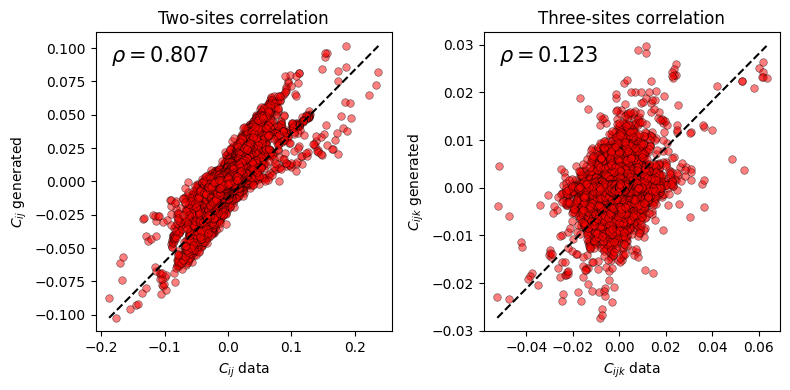

In [ ]:
#@title Inspect two and three sites correlations

from adabmDCA.stats import get_correlation_two_points, get_freq_three_points, extract_Cij_from_freq

# Extract the entries of the three sites connected correlation function (Cijk) for a predefined number of triplets
#@markdown Mark true to evaluate the three-body correlations. It might take a lot of time!
compute_three_body = True # @param {type:"boolean"}
#@markdown Number of triplets to evaluate for three-body correlations
ntriples = 100 # @param {"type": "integer"}
#@markdown ---

# one and two sites frequencies of the generated data
pi = get_freq_single_point(gen)
pij = get_freq_two_points(gen)
# Pearson and slope of generated vs natural two point connected correlation matrices
pearson_cij, slope_cij = get_correlation_two_points(fi=fi_target, fij=fij_target, pi=pi, pij=pij)
# Extract the lower-triangular Cij entries for plotting
cij_data, cij_gen = extract_Cij_from_freq(fij=fij_target, pi=pi, pij=pij, fi=fi_target)

if compute_three_body:
    cijk_data, cijk_gen = get_freq_three_points(msa_oh, gen, ntriplets=10000, weights=weights, device=device)
    pearson_cijk = torch.corrcoef(torch.stack([cijk_data, cijk_gen]))[0, 1].item()

#@markdown Figure resolution
dpi = 100 #@param {"type": "integer"}
nrows = 2 if compute_three_body else 1
fig, ax = plt.subplots(1, nrows, figsize=(8, 4), dpi=dpi)
if not compute_three_body:
    ax = [ax,]

ax[0].scatter(cij_data.cpu().numpy(), cij_gen.cpu().numpy(), c="red", edgecolor="black", s=30, lw=0.5, alpha=0.5)
ax[0].plot([cij_data.min().item(), cij_data.max().item()], [cij_gen.min().item(), cij_gen.max().item()], c="black", linestyle="--")
ax[0].set_xlabel(r"$C_{ij}$ data")
ax[0].set_ylabel(r"$C_{ij}$ generated")
ax[0].annotate(r"$\rho=$" + f"{pearson_cij:.3f}", xy=(0.05, 0.9), xycoords='axes fraction', fontsize=15)
ax[0].set_title("Two-sites correlation")

if compute_three_body:
    ax[1].scatter(cijk_data.cpu().numpy(), cijk_gen.cpu().numpy(), c="red", edgecolor="black", s=30, lw=0.5, alpha=0.5)
    ax[1].plot([cijk_data.min().item(), cijk_data.max().item()], [cijk_gen.min().item(), cijk_gen.max().item()], c="black", linestyle="--")
    ax[1].set_xlabel(r"$C_{ijk}$ data")
    ax[1].set_ylabel(r"$C_{ijk}$ generated")
    ax[1].annotate(r"$\rho=$" + f"{pearson_cijk:.3f}", xy=(0.05, 0.9), xycoords='axes fraction', fontsize=15)
    ax[1].set_title("Three-sites correlation")

plt.tight_layout()

In [ ]:
#@title Download generated sequences
#@markdown Run this cell to download the sequences generated with bmDCA

from adabmDCA.fasta import write_fasta

try:
    path_gen = os.path.join(jobname, "generated_msa.fasta")
    headers = [f"gen_{i}" for i in range(len(gen))]
    write_fasta(
       path_gen,
       headers=headers,
       sequences=gen.argmax(-1).cpu().numpy(),
       tokens=tokens,
    )
    files.download(path_gen)
except:
    print("No sequences generated")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Additional analysis

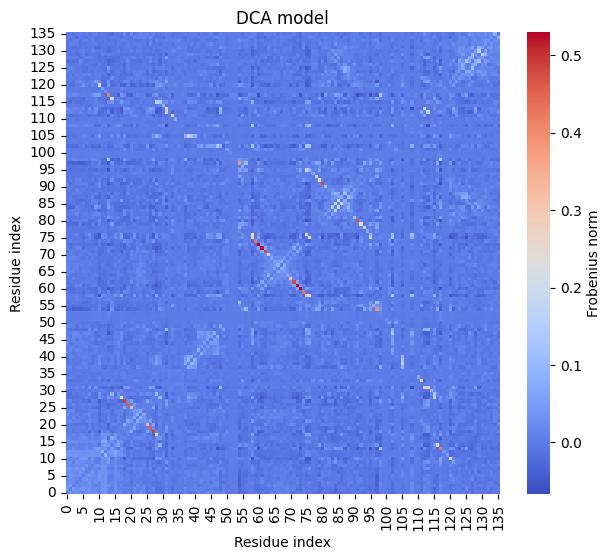

In [ ]:
#@title Contact map

from adabmDCA.dca import get_contact_map, get_mf_contact_map
from adabmDCA.plot import plot_contact_map
method = "DCA model" #@param ["mfDCA", "DCA model"]
dpi = 100 #@param {"type": "integer"}

if method == "mfDCA":
    cm = get_mf_contact_map(data=msa_oh, tokens=tokens, weights=weights)
else:
    cm = get_contact_map(params=params, tokens=tokens)

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=dpi)
ax = plot_contact_map(ax=ax, cm=cm, title=method)

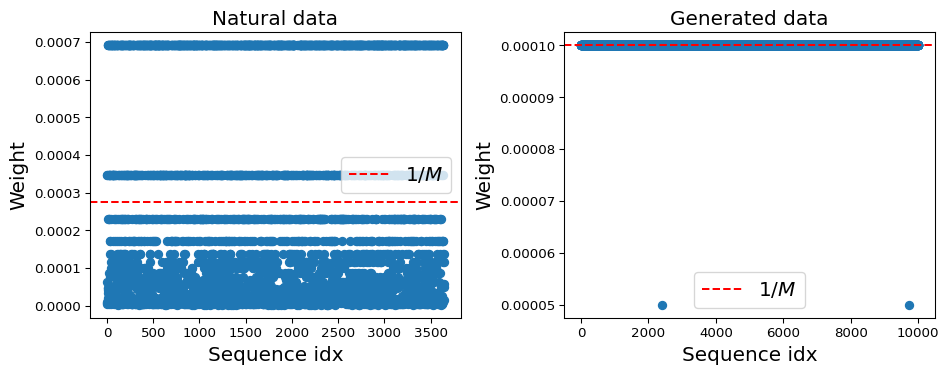

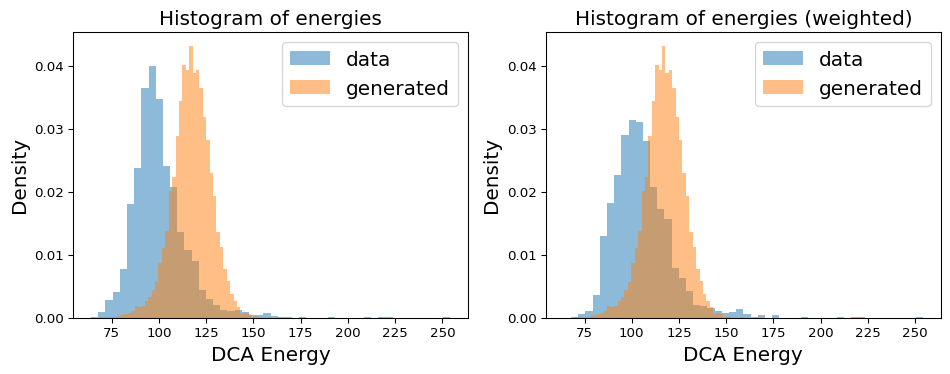

In [ ]:
#@title Sequence weights and DCA energy distributions

weights_gen = compute_weights(gen.argmax(-1), device=device, dtype=dtype)
weights_gen_norm = weights_gen / weights_gen.sum()
weights_norm = weights / weights.sum()

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=96)
ax[0].plot(weights_norm.cpu().numpy(), "o")
ax[0].axhline(1/len(weights), color="red", ls="--", label=r"$1/M$")
ax[0].set_title("Natural data", fontsize=15)
ax[0].set_xlabel("Sequence idx", fontsize=15)
ax[0].set_ylabel("Weight", fontsize=15)
ax[0].legend(fontsize=15)

ax[1].plot(weights_gen_norm.cpu().numpy(), "o")
ax[1].axhline(1/len(weights_gen), color="red", ls="--", label=r"$1/M$")
ax[1].set_title("Generated data", fontsize=15)
ax[1].set_xlabel("Sequence idx", fontsize=15)
ax[1].set_ylabel("Weight", fontsize=15)
ax[1].legend(fontsize=15)

fig.tight_layout()
plt.show()


from adabmDCA.statmech import compute_energy
energy_data = compute_energy(msa_oh, params).cpu().numpy()
energy_gen = compute_energy(gen, params).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=96)
ax[0].set_title("Histogram of energies", fontsize=15)
ax[0].hist(energy_data, bins=50, density=True, alpha=0.5, label="data")
ax[0].hist(energy_gen, bins=50, density=True, alpha=0.5, label="generated")
ax[0].set_xlabel("DCA Energy", fontsize=15)
ax[0].set_ylabel("Density", fontsize=15)
ax[0].legend(fontsize=15)

ax[1].set_title("Histogram of energies (weighted)", fontsize=15)
ax[1].hist(energy_data, weights=weights_norm.cpu().numpy(), bins=50, density=True, alpha=0.5, label="data")
ax[1].hist(energy_gen, weights=weights_gen_norm.cpu().numpy(), bins=50, density=True, alpha=0.5, label="generated")
ax[1].set_xlabel("DCA Energy", fontsize=15)
ax[1].set_ylabel("Density", fontsize=15)
ax[1].legend(fontsize=15)

fig.tight_layout()
plt.show()


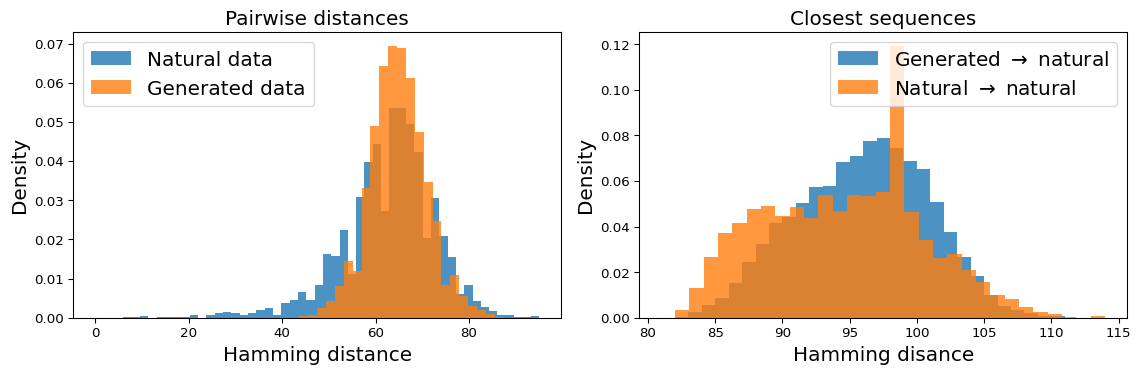

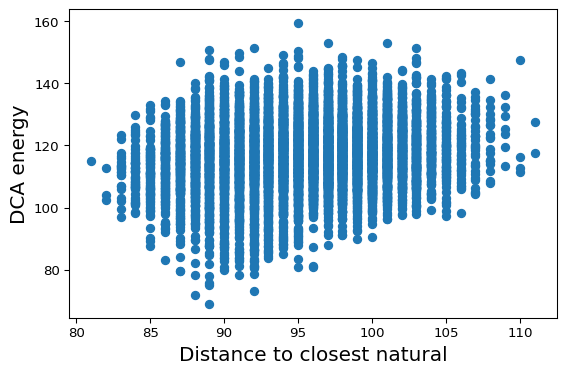

In [ ]:
#@title Pairwise distances

from adabmDCA.dca import get_seqid

seqids_11 = get_seqid(msa_oh).cpu().numpy()
seqids_22 = get_seqid(gen).cpu().numpy()
def get_minseqids(s1, s2):
    minseqids = []
    for s in s1:
        minseqids.append(get_seqid(s, s2).min().item())
    return np.array(minseqids)

min_seqids_12 = get_minseqids(gen, msa_oh)
min_seqids_11 = get_minseqids(msa_oh, msa_oh)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=96)
ax[0].hist(L - seqids_11, bins=50, density=True, alpha=0.8, label="Natural data")
ax[0].hist(L - seqids_22, bins=50, density=True, alpha=0.8, label="Generated data")
ax[0].set_title("Pairwise distances", fontsize=15)
ax[0].set_xlabel("Hamming distance", fontsize=15)
ax[0].set_ylabel("Density", fontsize=15)
ax[0].legend(fontsize=15)

ax[1].hist(L - min_seqids_12, bins=30, density=True, alpha=0.8, label=r"Generated $\rightarrow$ natural")
ax[1].hist(L - min_seqids_11, bins=30, density=True, alpha=0.8, label=r"Natural $\rightarrow$ natural")
ax[1].set_title("Closest sequences", fontsize=15)
ax[1].set_xlabel("Hamming disance", fontsize=15)
ax[1].set_ylabel("Density", fontsize=15)
ax[1].legend(fontsize=15)

fig.tight_layout()
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=96)
ax.scatter(L - min_seqids_12, energy_gen)
ax.set_xlabel("Distance to closest natural", fontsize=15)
ax.set_ylabel("DCA energy", fontsize=15)
fig.tight_layout()
plt.show()